<a href="https://colab.research.google.com/github/padhab34-bit/IML/blob/main/bcan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:

breast_cancer = load_breast_cancer()


In [3]:
# Check the shape of the data
print(f"Data shape: {breast_cancer.data.shape}")
print(f"Target shape: {breast_cancer.target.shape}")
print(f"Feature names: {breast_cancer.feature_names}")
print(f"Target names: {breast_cancer.target_names}")

Data shape: (569, 30)
Target shape: (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data, breast_cancer.target, test_size=0.20, random_state=42
)

In [5]:
# Display the sizes of the sets
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 30)
y_train shape: (455,)
X_test shape: (114, 30)
y_test shape: (114,)


In [6]:
# Gaussian Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)
print("GaussianNB model trained successfully.")

GaussianNB model trained successfully.


In [7]:
# Make predictions
y_pred = nb.predict(X_test)

# Estimator Method score
accuracy = nb.score(X_test, y_test)
print(f"Model accuracy using .score() method: {accuracy:.4f}")

Model accuracy using .score() method: 0.9737


In [8]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[40  3]
 [ 0 71]]


In [9]:
# Generate the classification report
report = classification_report(y_test, y_pred, target_names=breast_cancer.target_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



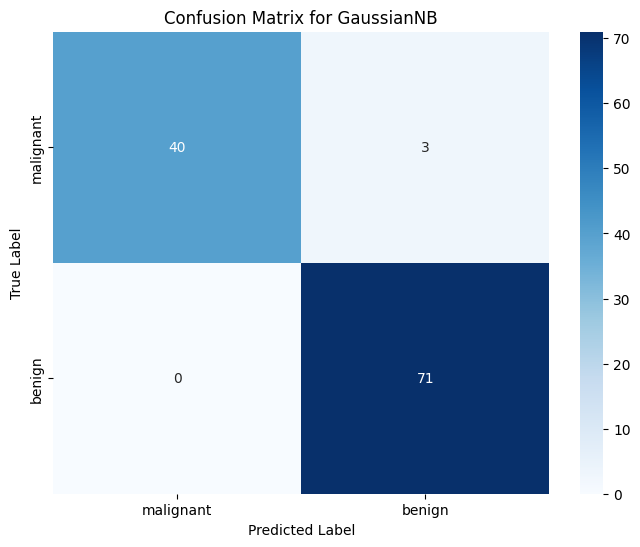

In [10]:
# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names, ax=ax)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for GaussianNB')
plt.show()

In [11]:
# Initialize KFold
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

# Perform K-Fold cross-validation
scores = cross_val_score(estimator=nb, X=breast_cancer.data, y=breast_cancer.target, cv=kfold)

print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {np.mean(scores):.4f}")
print(f"Standard deviation of cross-validation scores: {np.std(scores):.4f}")

Cross-validation scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean cross-validation score: 0.9385
Standard deviation of cross-validation scores: 0.0275


In [12]:
# Define a dictionary of estimators
estimators = {
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', multi_class='ovr', max_iter=10000, random_state=42),
    'SVC': SVC(gamma='scale', random_state=42)
}

results = {}

# Iterate through each model, train, predict, and evaluate
print("\n--- Evaluating Multiple Models ---")
for name, model in estimators.items():
    print(f"\nEvaluating {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred_multi = model.predict(X_test)

    # Evaluate accuracy
    accuracy_multi = model.score(X_test, y_test)
    print(f"  Accuracy: {accuracy_multi:.4f}")

    # Get classification report
    report_multi = classification_report(y_test, y_pred_multi, target_names=breast_cancer.target_names, output_dict=True)
    print("  Classification Report:")
    print(classification_report(y_test, y_pred_multi, target_names=breast_cancer.target_names))

    results[name] = {
        'accuracy': accuracy_multi,
        'report': report_multi,
        'confusion_matrix': confusion_matrix(y_test, y_pred_multi)
    }

# Display a summary of results
print("\n--- Summary of Model Accuracies ---")
for name, res in results.items():
    print(f"{name}: {res['accuracy']:.4f}")


--- Evaluating Multiple Models ---

Evaluating GaussianNB...
  Accuracy: 0.9737
  Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Evaluating KNeighborsClassifier...
  Accuracy: 0.9561
  Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.88      0.94        43
      benign       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114


Evaluating LogisticRegression...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Accuracy: 0.9561
  Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Evaluating SVC...
  Accuracy: 0.9474
  Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.86      0.93        43
      benign       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Summary of Model Accuracies ---
GaussianNB: 0.9737
KNeighborsClassifier: 0.9561
LogisticRegression: 0.9561
SVC: 0.9474
